# Employee Productivity Analysis
This notebook cleans the dataset and explores relationships connected to employee productiveness to further our understanding of where efficient business decisions can be made.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
# Load dataset and display basic information
df = pd.read_csv("data/raw_employee_dataset.csv")

print(f"Shape: {df.shape}")

print("\nColumn/s with missing values:")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\nDataset Info:")
df.info()


Shape: (1197, 15)

Column/s with missing values:
wip    506
dtype: int64

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   str    
 1   quarter                1197 non-null   str    
 2   department             1197 non-null   str    
 3   day                    1197 non-null   str    
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non

In [38]:
# Remove column with too many missing values
df = df.drop(columns=["wip"], errors="ignore")

# Remove missing rows
df = df.dropna()

df["productivity_pct_diff"] = (
    (df["actual_productivity"] - df["targeted_productivity"]) 
    / df["targeted_productivity"]
)
# Outlier removal using Z-score on "productivity_pct_diff"
z = ((df["productivity_pct_diff"] - df["productivity_pct_diff"].mean()) / df["productivity_pct_diff"].std())
df_clean = df[z.abs() < 3].copy()

print(f"Original rows: {len(df)}")
print(f"Clean rows: {len(df_clean)}")

Original rows: 1197
Clean rows: 1186


In [39]:
# FEATURE ENGINEERING (DEFINE METRICS)

# Productivity gap
df_clean["productivity_gap"] = (
    df_clean["actual_productivity"] - df_clean["targeted_productivity"]
)

# Efficiency per worker
df_clean["productivity_per_worker"] = (
    df_clean["actual_productivity"] / df_clean["no_of_workers"]
)

In [40]:
# TEAM-LEVEL SUMMARY (MAIN DATASET)
team_summary = df_clean.groupby("team").agg({
    "actual_productivity": "mean",
    "targeted_productivity": "mean",
    "productivity_gap": "mean",
    "over_time": "mean",
    "incentive": "mean",
    "no_of_workers": "mean"
}).reset_index()

# Ensure teams are ordered numerically
team_summary["team"] = team_summary["team"].astype(int)
team_summary = team_summary.sort_values("team")

In [41]:
# VISUAL ANALYSIS SETUP

# Define percent difference from target productivity
df_clean["productivity_pct_diff"] = (
    (df_clean["actual_productivity"] - df_clean["targeted_productivity"])
    / df_clean["targeted_productivity"]
) * 100

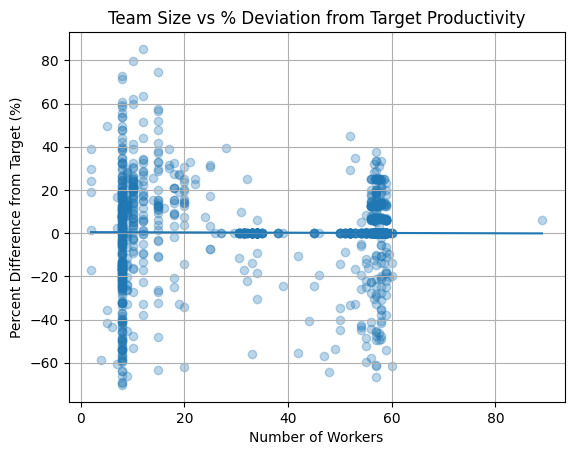

                 productivity_pct_diff  idle_time    over_time  incentive
team_size_group                                                          
0-30                          1.366583   0.000000  1929.240000  30.348000
30-60                        -0.554093   1.274052  6522.055394  44.553936


In [42]:
# 1. Team Size vs Productivity Percent Deviation from Target
x = df_clean["no_of_workers"]
y = df_clean["productivity_pct_diff"]

# Remove NaNs
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# Trend line
m, b = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

plt.figure()
plt.scatter(x, y, alpha=0.3)
plt.plot(x_line, y_line)

plt.title("Team Size vs % Deviation from Target Productivity")
plt.xlabel("Number of Workers")
plt.ylabel("Percent Difference from Target (%)")
plt.grid(True)
plt.show()

# Time size correlation with other metrics
df_clean["team_size_group"] = df_clean["no_of_workers"].apply(
    lambda x: "0-30" if x <= 30 else "30-60"
)

size_group_summary = df_clean.groupby("team_size_group")[[
    "productivity_pct_diff",
    "idle_time",
    "over_time",
    "incentive"
]].mean()

print(size_group_summary)

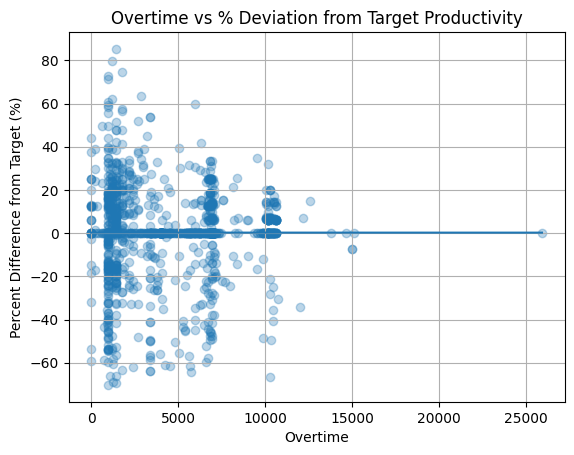

In [43]:
# 2. Overtime vs % Deviation (Overall)
x = df_clean["over_time"]
y = df_clean["productivity_pct_diff"]

mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

m, b = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

plt.figure()
plt.scatter(x, y, alpha=0.3)
plt.plot(x_line, y_line)

plt.title("Overtime vs % Deviation from Target Productivity")
plt.xlabel("Overtime")
plt.ylabel("Percent Difference from Target (%)")
plt.grid(True)
plt.show()

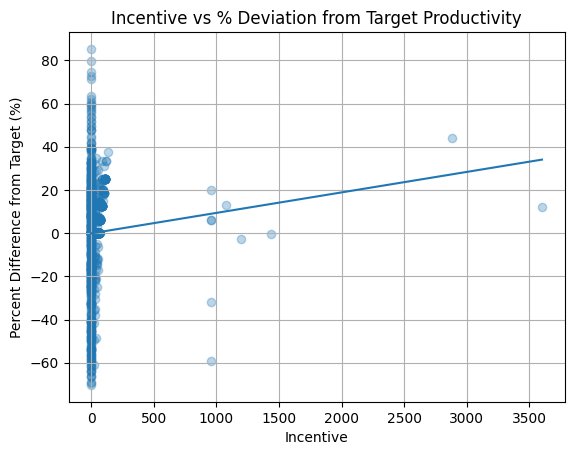

In [44]:
# 3. Incentive vs % Deviation (Overall)
x = df_clean["incentive"]
y = df_clean["productivity_pct_diff"]

mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

m, b = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

plt.figure()
plt.scatter(x, y, alpha=0.3)
plt.plot(x_line, y_line)

plt.title("Incentive vs % Deviation from Target Productivity")
plt.xlabel("Incentive")
plt.ylabel("Percent Difference from Target (%)")
plt.grid(True)
plt.show()

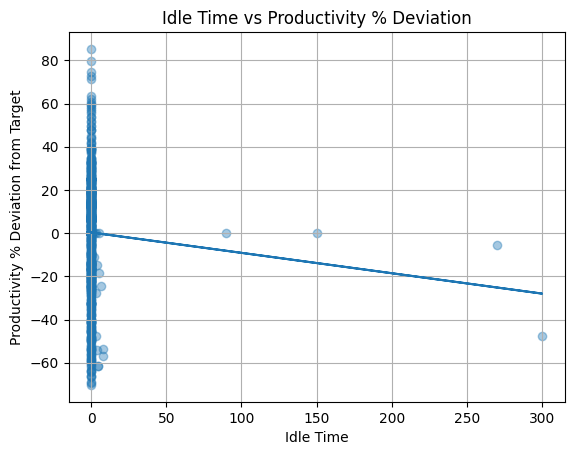

In [45]:
# 4. Idle time vs % Deviation (Overall)
# X and Y
x = df_clean["idle_time"]
y = df_clean["productivity_pct_diff"]

# Remove NaNs (important for polyfit)
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# Trend line (linear regression)
m, b = np.polyfit(x, y, 1)

# Plot
plt.figure()
plt.scatter(x, y, alpha=0.4)

# Trend line
plt.plot(x, m*x + b)

# Labels
plt.title("Idle Time vs Productivity % Deviation")
plt.xlabel("Idle Time")
plt.ylabel("Productivity % Deviation from Target")
plt.grid(True)

plt.show()

## Observations and Business Insights

### 1. Team Size and Productivity
- Team size shows no meaningful relationship with deviation from target productivity. 
- Performance remains relatively stable across different team sizes, suggesting that team size is likely not a primary driver of productivity differences in this dataset.

### 2. Overtime and Productivity
- Overtime shows little to no correlation with productivity deviation.
- Increased working hours do not consistently improve performance relative to targets, suggesting that simply allocating more time or labor does not effectively address productivity gaps.

### 3. Incentives and Productivity
- Incentives show a moderate positive relationship with productivity deviation.
- Incentives are generally associated with improved performance, though loosely; particularly high incentives still have mixed results.
- While not perfectly consistent, incentives appear to be one of the more influential factors in this dataset.

### 4. Idle Time and Productivity
- Idle time shows a clear negative relationship with productivity deviation.
- Higher idle time is consistently associated with lower performance relative to targets.
- This suggests that inefficiencies in workflow or resource utilization are a key driver of underperformance.

## Business Interpretation
- Among the variables analyzed, idle time and incentives are the only factors showing meaningful relationships with productivity.
- Idle time emerges as the strongest negative driver, indicating that reducing inefficiencies and workflow delays is likely the most effective way to improve performance.
- Incentives show a positive but moderate impact, suggesting they can support productivity improvements but are not sufficient on their own.
- In contrast, team size and overtime do not appear to significantly influence productivity, indicating that increasing workforce size or working hours is unlikely to yield meaningful results.
- Overall, the data suggests that operational efficiency (reducing idle time) is a more impactful lever than structural changes (team size) or labor expansion (overtime).